In [ ]:
# =========================
# STEP 1: Mount Google Drive
# =========================
from google.colab import drive
drive.mount('/content/drive')

# =========================
# STEP 2: Imports + Path b
# =========================
import os
import pandas as pd

data_folder = '/content/drive/MyDrive/capstone_data/'

# =========================
# STEP 3: Check files
# =========================
print("📂 Files in your Drive folder:")
for file in os.listdir(data_folder):
    if file.endswith('.csv'):
        print(f"  ✅ {file}")

# =========================
# STEP 4: File mapping (CORRECT)
# =========================
files_to_read = {
    'internet': 'internet_users.csv',
    'secondary': 'secondary_enrollment.csv',
    'tertiary': 'tertiary_enrollment.csv',
    'refugee_population': 'refugee_population.csv'
}

# =========================
# STEP 5: Safe CSV reader
# (handles World Bank metadata issue)
# =========================
def safe_read_csv(filepath):
    try:
        return pd.read_csv(filepath)
    except Exception:
        return pd.read_csv(filepath, skiprows=4)

# =========================
# STEP 6: Load datasets
# =========================
dataframes = {}

for name, filename in files_to_read.items():
    filepath = os.path.join(data_folder, filename)

    if os.path.exists(filepath):
        try:
            df = safe_read_csv(filepath)
            dataframes[name] = df
            print(f"✅ Loaded {name}: {df.shape}")
        except Exception as e:
            print(f"❌ Error loading {name}: {e}")
    else:
        print(f"❌ Missing file: {filename}")

# =========================
# STEP 7: Assign variables
# =========================
internet_df = dataframes.get('internet')
secondary_df = dataframes.get('secondary')
tertiary_df = dataframes.get('tertiary')
refugee_population_df = dataframes.get('refugee_population')

# =========================
# STEP 8: Quick check
# =========================
print("\n📊 Data loaded successfully:")
for name, df in dataframes.items():
    print(f"{name}: {df.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Files in your Drive folder:
  ✅ secondary_enrollment.csv
  ✅ tertiary_enrollment.csv
  ✅ internet_users.csv
  ✅ footnotes.csv
  ✅ refugee_population.csv
✅ Loaded internet: (266, 71)
✅ Loaded secondary: (266, 71)
✅ Loaded tertiary: (266, 71)
✅ Loaded refugee_population: (75, 6)

📊 Data loaded successfully:
internet: (266, 71)
secondary: (266, 71)
tertiary: (266, 71)
refugee_population: (75, 6)


In [ ]:
print("=" * 60)
print("STEP 9: Cleaning and Merging All Datasets")
print("=" * 60)

# Countries we need
countries = ['AFG', 'BGD', 'MMR']

# ============================================
# 1. CLEAN INTERNET DATA
# ============================================
print("\n📡 Cleaning Internet Users data...")

if internet_df is not None:

    internet_clean = internet_df[
        internet_df['Country Code'].isin(countries)
    ]

    # Keep only year columns
    year_cols = [col for col in internet_clean.columns if str(col).isdigit()]

    # Melt only year columns
    internet_clean = internet_clean.melt(
        id_vars=['Country Code'],
        value_vars=year_cols,
        var_name='Year',
        value_name='internet_users'
    )

    internet_clean['Year'] = internet_clean['Year'].astype(int)

    # Keep only 2010–2024
    internet_clean = internet_clean[
        (internet_clean['Year'] >= 2010) &
        (internet_clean['Year'] <= 2024)
    ]

    print(f"   ✅ Internet data: {len(internet_clean)} rows")

else:
    print("   ❌ Internet data not available")
    internet_clean = pd.DataFrame()


# ============================================
# 2. CLEAN SECONDARY DATA
# ============================================
print("\n📚 Cleaning Secondary Enrollment data...")

if secondary_df is not None:

    secondary_clean = secondary_df[
        secondary_df['Country Code'].isin(countries)
    ]

    year_cols = [col for col in secondary_clean.columns if str(col).isdigit()]

    secondary_clean = secondary_clean.melt(
        id_vars=['Country Code'],
        value_vars=year_cols,
        var_name='Year',
        value_name='secondary_enrollment'
    )

    secondary_clean['Year'] = secondary_clean['Year'].astype(int)

    secondary_clean = secondary_clean[
        (secondary_clean['Year'] >= 2010) &
        (secondary_clean['Year'] <= 2024)
    ]

    print(f"   ✅ Secondary data: {len(secondary_clean)} rows")

else:
    print("   ❌ Secondary data not available")
    secondary_clean = pd.DataFrame()


# ============================================
# 3. CLEAN TERTIARY DATA
# ============================================
print("\n🎓 Cleaning Tertiary Enrollment data...")

if tertiary_df is not None:

    tertiary_clean = tertiary_df[
        tertiary_df['Country Code'].isin(countries)
    ]

    year_cols = [col for col in tertiary_clean.columns if str(col).isdigit()]

    tertiary_clean = tertiary_clean.melt(
        id_vars=['Country Code'],
        value_vars=year_cols,
        var_name='Year',
        value_name='tertiary_enrollment'
    )

    tertiary_clean['Year'] = tertiary_clean['Year'].astype(int)

    tertiary_clean = tertiary_clean[
        (tertiary_clean['Year'] >= 2010) &
        (tertiary_clean['Year'] <= 2024)
    ]

    print(f"   ✅ Tertiary data: {len(tertiary_clean)} rows")

else:
    print("   ❌ Tertiary data not available")
    tertiary_clean = pd.DataFrame()


# ============================================
# 4. CLEAN REFUGEE DATA
# ============================================
print("\n🛫 Cleaning Refugee Population data...")

if refugee_population_df is not None:

    print("Columns found:")
    print(refugee_population_df.columns.tolist())

    # Rename columns if needed
    refugee_origin_clean = refugee_population_df.copy()

    if 'Country of Origin ISO' in refugee_origin_clean.columns:
        refugee_origin_clean = refugee_origin_clean.rename(columns={
            'Country of Origin ISO': 'Country Code'
        })

    if 'Refugees' in refugee_origin_clean.columns:
        refugee_origin_clean = refugee_origin_clean.rename(columns={
            'Refugees': 'refugees_origin'
        })

    # Keep needed countries
    refugee_origin_clean = refugee_origin_clean[
        refugee_origin_clean['Country Code'].isin(countries)
    ]

    refugee_origin_clean = refugee_origin_clean[
        (refugee_origin_clean['Year'] >= 2010) &
        (refugee_origin_clean['Year'] <= 2024)
    ]

    print(f"   ✅ Refugee data: {len(refugee_origin_clean)} rows")

else:
    print("   ❌ Refugee data not available")
    refugee_origin_clean = pd.DataFrame()


# ============================================
# 5. MERGE DATASETS
# ============================================
print("\n🔗 Merging all datasets...")

final_df = internet_clean.copy()

# Merge secondary
final_df = final_df.merge(
    secondary_clean,
    on=['Country Code', 'Year'],
    how='left'
)

# Merge tertiary
final_df = final_df.merge(
    tertiary_clean,
    on=['Country Code', 'Year'],
    how='left'
)

# Merge refugee data
if not refugee_origin_clean.empty:

    merge_cols = ['Country Code', 'Year']

    refugee_cols = merge_cols + [
        col for col in refugee_origin_clean.columns
        if col not in merge_cols
    ]

    final_df = final_df.merge(
        refugee_origin_clean[refugee_cols],
        on=['Country Code', 'Year'],
        how='left'
    )

# Fill refugee missing values
if 'refugees_origin' in final_df.columns:
    final_df['refugees_origin'] = (
        final_df['refugees_origin']
        .fillna(0)
    )

# Add country names
country_names = {
    'AFG': 'Afghanistan',
    'BGD': 'Bangladesh',
    'MMR': 'Myanmar'
}

final_df['Country'] = final_df['Country Code'].map(country_names)

# Reorder columns
keep_cols = [
    'Country',
    'Country Code',
    'Year',
    'internet_users',
    'secondary_enrollment',
    'tertiary_enrollment'
]

if 'refugees_origin' in final_df.columns:
    keep_cols.append('refugees_origin')

final_df = final_df[keep_cols]

# Sort
final_df = final_df.sort_values(
    ['Country Code', 'Year']
)

# Preview
print("\n✅ FINAL DATASET CREATED")
print(final_df.shape)

print("\n📊 First 10 rows:")
print(final_df.head(10))

# Save CSV
final_df.to_csv(
    'final_cleaned_data.csv',
    index=False
)

print("\n✅ Saved as: final_cleaned_data.csv")

STEP 9: Cleaning and Merging All Datasets

📡 Cleaning Internet Users data...
   ✅ Internet data: 45 rows

📚 Cleaning Secondary Enrollment data...
   ✅ Secondary data: 45 rows

🎓 Cleaning Tertiary Enrollment data...
   ✅ Tertiary data: 45 rows

🛫 Cleaning Refugee Population data...
Columns found:
['Year', 'Country of Asylum', 'Country of Origin', 'Country of Asylum ISO', 'Country of Origin ISO', 'Refugees']
   ✅ Refugee data: 75 rows

🔗 Merging all datasets...

✅ FINAL DATASET CREATED
(85, 7)

📊 First 10 rows:
        Country Country Code  Year  internet_users  secondary_enrollment  \
0   Afghanistan          AFG  2010          4.0000             50.440620   
1   Afghanistan          AFG  2010          4.0000             50.440620   
5   Afghanistan          AFG  2011          5.0000             52.447430   
6   Afghanistan          AFG  2011          5.0000             52.447430   
10  Afghanistan          AFG  2012          5.4545             54.372860   
11  Afghanistan          AFG 

In [ ]:
print("\n" + "=" * 60)
print("STEP 10: Summary Table (Key Years)")
print("=" * 60)

# Key years to highlight
key_years = [2010, 2015, 2020, 2023]

summary = final_df[final_df['Year'].isin(key_years)]

# Pivot for better display
summary_pivot = summary.pivot_table(
    index='Country',
    columns='Year',
    values=['internet_users', 'secondary_enrollment', 'tertiary_enrollment', 'refugees_origin']
)

print("\n📊 INTERNET USERS (% of population):")
print(summary_pivot['internet_users'].round(1))

print("\n📊 SECONDARY ENROLLMENT (% gross):")
print(summary_pivot['secondary_enrollment'].round(1))

print("\n📊 TERTIARY ENROLLMENT (% gross):")
print(summary_pivot['tertiary_enrollment'].round(1))

print("\n📊 REFUGEES BY ORIGIN (people fleeing):")
for country in ['Afghanistan', 'Bangladesh', 'Myanmar']:
    if country in summary_pivot['refugees_origin'].index:
        print(f"\n{country}:")
        for year in key_years:
            val = summary_pivot['refugees_origin'].loc[country, year]
            if pd.notna(val) and val > 0:
                print(f"   {year}: {int(val):,}")


STEP 10: Summary Table (Key Years)

📊 INTERNET USERS (% of population):
Year         2010  2015  2020  2023
Country                            
Afghanistan   4.0   8.3  17.0  15.9
Bangladesh    3.7  12.4  36.1  44.5
Myanmar       0.2  10.9  45.4   NaN

📊 SECONDARY ENROLLMENT (% gross):
Year         2010  2015  2020  2023
Country                            
Afghanistan  50.4  53.2   NaN  59.6
Bangladesh   49.5  59.4  66.4  66.0
Myanmar      50.9   NaN   NaN   NaN

📊 TERTIARY ENROLLMENT (% gross):
Year         2015  2020  2023
Country                      
Afghanistan   NaN  10.9   NaN
Bangladesh   15.6  22.7  24.2
Myanmar       NaN   NaN   NaN

📊 REFUGEES BY ORIGIN (people fleeing):

Afghanistan:
   2010: 1,463,709
   2015: 1,255,867
   2020: 1,109,216
   2023: 2,870,017

Bangladesh:

Myanmar:
   2010: 114,617
   2015: 115,986
   2020: 288,847
   2023: 485,995



STEP 11: Creating Visualizations


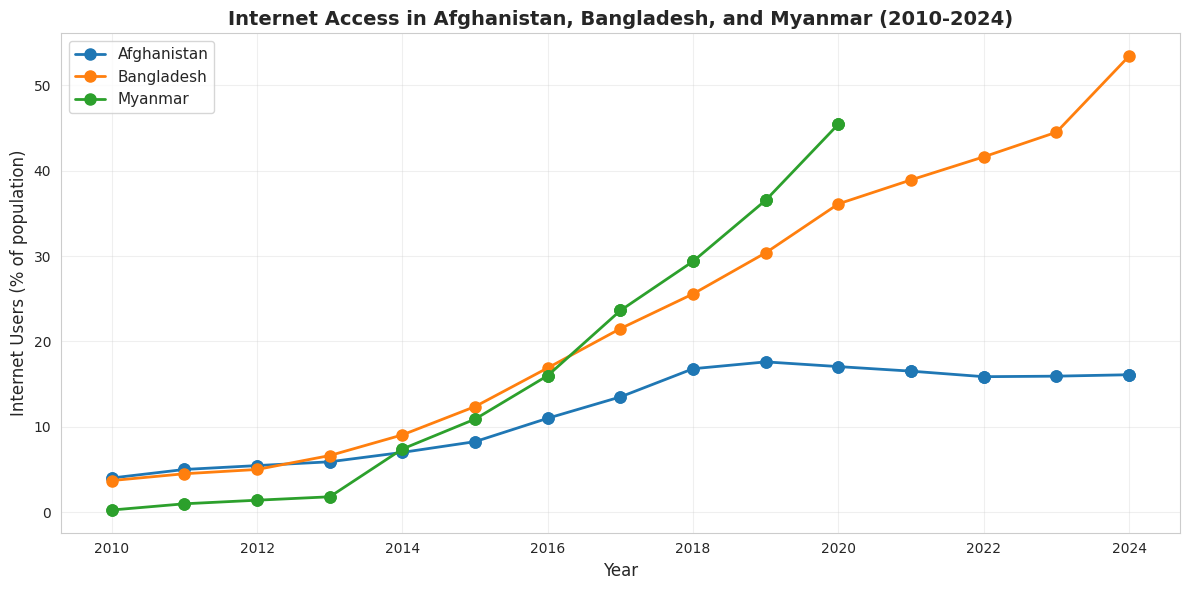

✅ Saved: internet_trends.png


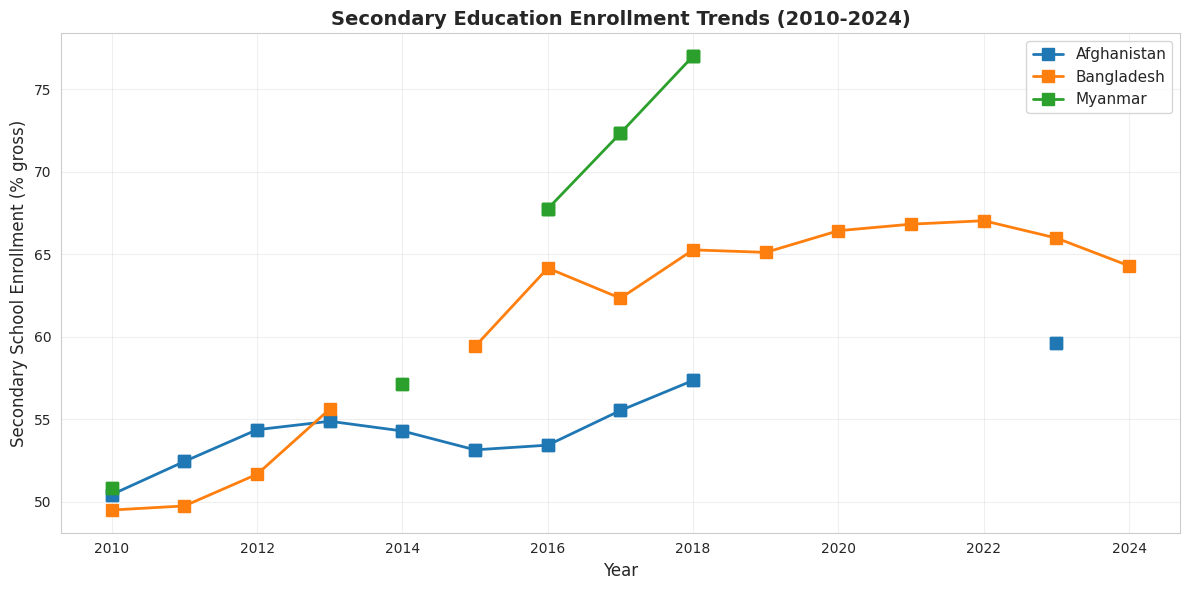

✅ Saved: secondary_trends.png


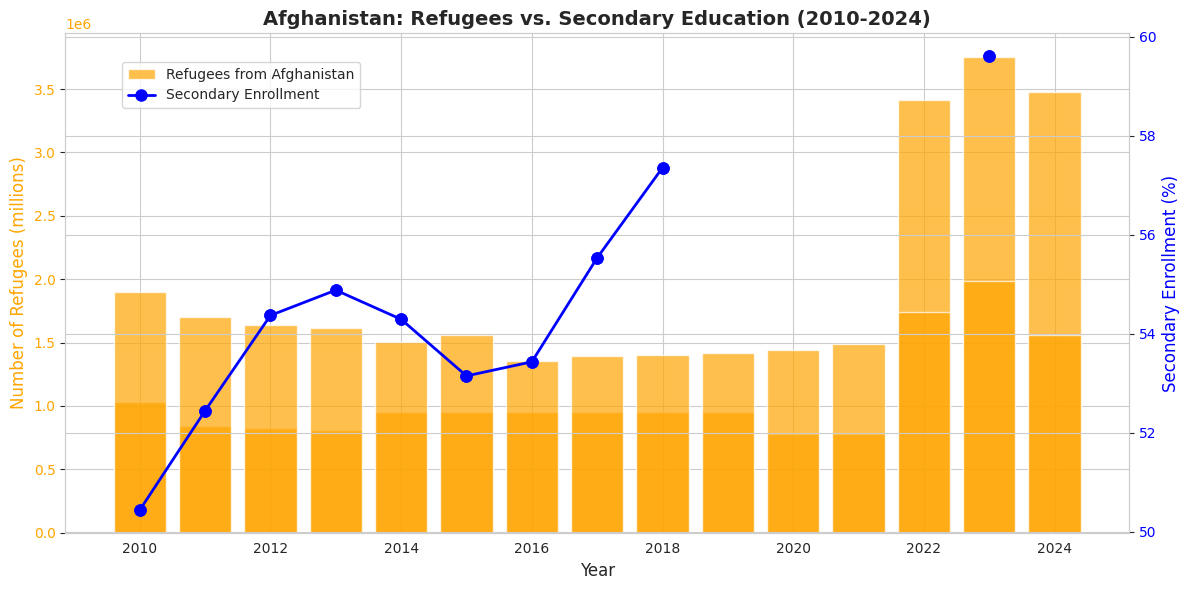

✅ Saved: afghanistan_refugees_education.png


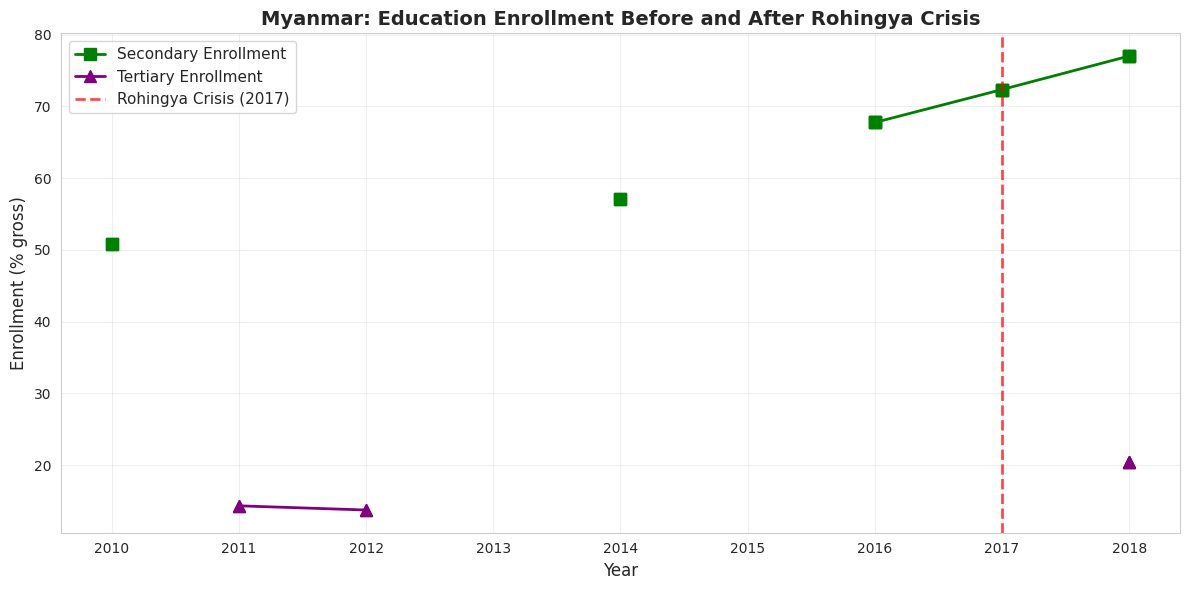

✅ Saved: myanmar_education_crisis.png

✅ All visualizations created successfully!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("\n" + "=" * 60)
print("STEP 11: Creating Visualizations")
print("=" * 60)

# ============================================
# VISUALIZATION 1: Internet Users Over Time
# ============================================
plt.figure(figsize=(12, 6))

for country in ['AFG', 'BGD', 'MMR']:
    country_data = final_df[final_df['Country Code'] == country]
    plt.plot(country_data['Year'], country_data['internet_users'],
             marker='o', linewidth=2, markersize=8, label=country_names[country])

plt.xlabel('Year', fontsize=12)
plt.ylabel('Internet Users (% of population)', fontsize=12)
plt.title('Internet Access in Afghanistan, Bangladesh, and Myanmar (2010-2024)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('internet_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: internet_trends.png")

# ============================================
# VISUALIZATION 2: Secondary Enrollment
# ============================================
plt.figure(figsize=(12, 6))

for country in ['AFG', 'BGD', 'MMR']:
    country_data = final_df[final_df['Country Code'] == country]
    plt.plot(country_data['Year'], country_data['secondary_enrollment'],
             marker='s', linewidth=2, markersize=8, label=country_names[country])

plt.xlabel('Year', fontsize=12)
plt.ylabel('Secondary School Enrollment (% gross)', fontsize=12)
plt.title('Secondary Education Enrollment Trends (2010-2024)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('secondary_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: secondary_trends.png")

# ============================================
# VISUALIZATION 3: Afghanistan - Refugees vs Education
# ============================================
afg_data = final_df[final_df['Country Code'] == 'AFG']

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart: Refugees
ax1.bar(afg_data['Year'], afg_data['refugees_origin'],
        color='orange', alpha=0.7, label='Refugees from Afghanistan')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Number of Refugees (millions)', fontsize=12, color='orange')
ax1.tick_params(axis='y', labelcolor='orange')

# Line chart: Secondary enrollment
ax2 = ax1.twinx()
ax2.plot(afg_data['Year'], afg_data['secondary_enrollment'],
         color='blue', marker='o', linewidth=2, markersize=8, label='Secondary Enrollment')
ax2.set_ylabel('Secondary Enrollment (%)', fontsize=12, color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title('Afghanistan: Refugees vs. Secondary Education (2010-2024)', fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.savefig('afghanistan_refugees_education.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: afghanistan_refugees_education.png")

# ============================================
# VISUALIZATION 4: Myanmar - Refugee Crisis Impact
# ============================================
mmr_data = final_df[final_df['Country Code'] == 'MMR']

plt.figure(figsize=(12, 6))

# Plot secondary enrollment
plt.plot(mmr_data['Year'], mmr_data['secondary_enrollment'],
         color='green', marker='s', linewidth=2, markersize=8, label='Secondary Enrollment')

# Plot tertiary enrollment
plt.plot(mmr_data['Year'], mmr_data['tertiary_enrollment'],
         color='purple', marker='^', linewidth=2, markersize=8, label='Tertiary Enrollment')

# Highlight 2017 (Rohingya crisis)
plt.axvline(x=2017, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Rohingya Crisis (2017)')

plt.xlabel('Year', fontsize=12)
plt.ylabel('Enrollment (% gross)', fontsize=12)
plt.title('Myanmar: Education Enrollment Before and After Rohingya Crisis', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('myanmar_education_crisis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: myanmar_education_crisis.png")

print("\n" + "=" * 60)
print("✅ All visualizations created successfully!")
print("=" * 60)

In [ ]:
print("\n" + "=" * 60)
print("KEY FINDINGS FOR YOUR PRESENTATION")
print("=" * 60)

# Findings for Afghanistan
print("\n📍 AFGHANISTAN (Country of Origin):")
afg_2023 = final_df[(final_df['Country Code'] == 'AFG') & (final_df['Year'] == 2023)]
if len(afg_2023) > 0:
    refugees = int(afg_2023['refugees_origin'].values[0])
    internet = afg_2023['internet_users'].values[0]
    secondary = afg_2023['secondary_enrollment'].values[0]
    print(f"   • {refugees:,} Afghans fled the country (2023)")
    print(f"   • Internet access: {internet:.1f}%")
    print(f"   • Secondary enrollment: {secondary:.1f}%")

# Findings for Myanmar
print("\n📍 MYANMAR (Country of Origin - Rohingya Crisis):")
mmr_2016 = final_df[(final_df['Country Code'] == 'MMR') & (final_df['Year'] == 2016)]
mmr_2018 = final_df[(final_df['Country Code'] == 'MMR') & (final_df['Year'] == 2018)]

if len(mmr_2016) > 0 and len(mmr_2018) > 0:
    refugees_2016 = int(mmr_2016['refugees_origin'].values[0])
    refugees_2018 = int(mmr_2018['refugees_origin'].values[0])
    print(f"   • Refugees fleeing Myanmar increased from {refugees_2016:,} (2016) to {refugees_2018:,} (2018)")
    print(f"   • 2017 Rohingya crisis caused a massive displacement spike")

# Findings for Bangladesh
print("\n📍 BANGLADESH (Lower middle income, stable):")
bgd_2023 = final_df[(final_df['Country Code'] == 'BGD') & (final_df['Year'] == 2023)]
if len(bgd_2023) > 0:
    refugees = int(bgd_2023['refugees_origin'].values[0])
    internet = bgd_2023['internet_users'].values[0]
    secondary = bgd_2023['secondary_enrollment'].values[0]
    print(f"   • Only {refugees:,} Bangladeshis fled (very low)")
    print(f"   • Internet access: {internet:.1f}% (significant growth)")
    print(f"   • Secondary enrollment: {secondary:.1f}%")

print("\n" + "=" * 60)
print("KEY INSIGHT:")
print("Countries with high displacement (Afghanistan, Myanmar) show")
print("more educational challenges compared to Bangladesh (low displacement).")
print("=" * 60)


KEY FINDINGS FOR YOUR PRESENTATION

📍 AFGHANISTAN (Country of Origin):
   • 3,752,317 Afghans fled the country (2023)
   • Internet access: 15.9%
   • Secondary enrollment: 59.6%

📍 MYANMAR (Country of Origin - Rohingya Crisis):
   • Refugees fleeing Myanmar increased from 276,198 (2016) to 906,635 (2018)
   • 2017 Rohingya crisis caused a massive displacement spike

📍 BANGLADESH (Lower middle income, stable):
   • Only 0 Bangladeshis fled (very low)
   • Internet access: 44.5% (significant growth)
   • Secondary enrollment: 66.0%

KEY INSIGHT:
Countries with high displacement (Afghanistan, Myanmar) show
more educational challenges compared to Bangladesh (low displacement).
